# Prediction Suhu Udara

Nama: Yudha nuur cahyo

NIM: 220411100052

Mata Kuliah: Proyek sains Data

proyek ini untuk memprediksi suhu udara berdasarkan data historis menggunakan metode machine learning. Prosesnya melibatkan beberapa langkah utama, mulai dari memuat data, memprosesnya, melatih model, hingga membuat prediksi.

In [2]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np
import pickle

## Memuat dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')
import pickle
import pandas as pd

Mounted at /content/drive


In [4]:
data = pd.read_csv("/content/drive/My Drive/psd/dataset/prediksi_cuaca_permenit.csv")

In [5]:
data

,rowID,hpwren_timestamp,air_pressure,air_temp,avg_wind_direction,avg_wind_speed,max_wind_direction,max_wind_speed,min_wind_direction,min_wind_speed,rain_accumulation,rain_duration,relative_humidity
0,0,9/10/2011 0:00,912.3,64.76,97.0,1.2,106.0,1.6,85.0,1.0,NaN,NaN,60.5
1,1,9/10/2011 0:01,912.3,63.86,161.0,0.8,215.0,1.5,43.0,0.2,0.0,0.0,39.9
2,2,9/10/2011 0:02,912.3,64.22,77.0,0.7,143.0,1.2,324.0,0.3,0.0,0.0,43.0
3,3,9/10/2011 0:03,912.3,64.40,89.0,1.2,112.0,1.6,12.0,0.7,0.0,0.0,49.5
4,4,9/10/2011 0:04,912.3,64.40,185.0,0.4,260.0,1.0,100.0,0.1,0.0,0.0,58.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2003,2003,9/11/2011 9:23,916.8,57.92,207.0,1.8,213.0,2.2,200.0,1.5,0.0,0.0,73.8
2004,2004,9/11/2011 9:24,916.8,57.92,174.0,0.7,239.0,1.5,129.0,0.4,0.0,0.0,72.9
2005,2005,9/11/2011 9:25,916.9,58.10,177.0,1.9,196.0,2.2,140.0,1.4,0.0,0.0,73.8
2006,2006,9/11/2011 9:26,916.8,58.28,160.0,1.1,175.0,1.5,122.0,0.6,0.0,0.0,73.2


## Preprocessing: Extract Date Information

In [6]:
# Now you can access the columns by their names
data_filtered = data[['hpwren_timestamp', 'air_temp', 'air_pressure', 'avg_wind_speed', 'relative_humidity']]
data_filtered

,hpwren_timestamp,air_temp,air_pressure,avg_wind_speed,relative_humidity
0,9/10/2011 0:00,64.76,912.3,1.2,60.5
1,9/10/2011 0:01,63.86,912.3,0.8,39.9
2,9/10/2011 0:02,64.22,912.3,0.7,43.0
3,9/10/2011 0:03,64.40,912.3,1.2,49.5
4,9/10/2011 0:04,64.40,912.3,0.4,58.8
...,...,...,...,...,...
2003,9/11/2011 9:23,57.92,916.8,1.8,73.8
2004,9/11/2011 9:24,57.92,916.8,0.7,72.9
2005,9/11/2011 9:25,58.10,916.9,1.9,73.8
2006,9/11/2011 9:26,58.28,916.8,1.1,73.2


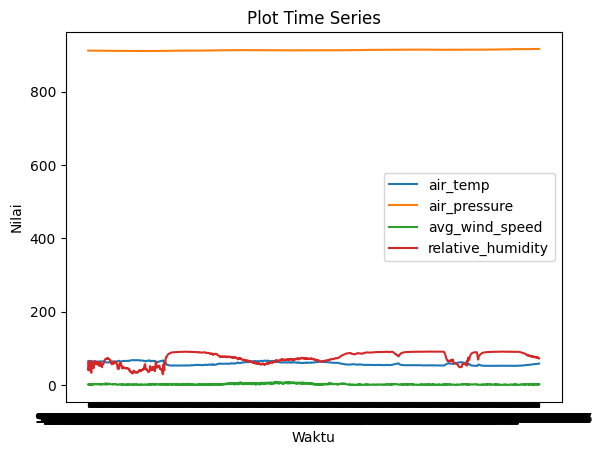

In [13]:
import matplotlib.pyplot as plt

# Visualisasi data time series
for column in ['air_temp', 'air_pressure', 'avg_wind_speed', 'relative_humidity']:
    plt.plot(data_filtered['hpwren_timestamp'], data_filtered[column], label=column)

plt.title('Plot Time Series')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend() # Add a legend to differentiate the lines
plt.show()

## Sliding Window

Membuat fitur dengan pendekatan sliding window dan menentukan target prediksi.

In [14]:
def create_sliding_window(data_filtered, window_size, target_column):
    X, y = [], []

    for i in range(len(data_filtered) - window_size):
        # Ambil fitur dalam window
        features = data_filtered.iloc[i:i+window_size].values  # Semua fitur
        X.append(features)

        # Ambil target (nilai air_temp di waktu berikutnya)
        target = data_filtered.iloc[i + window_size][target_column]
        y.append(target)

    return np.array(X), np.array(y)

# Ukuran window
window_size = 3

# Buat fitur (X) dan target (y)
X, y = create_sliding_window(data_filtered[["air_temp", "air_pressure", "avg_wind_speed", "relative_humidity"]],
                             window_size=window_size,
                             target_column="air_temp")

print("Shape X:", X.shape)
print("Shape y:", y.shape)


Shape X: (2005, 3, 4)
Shape y: (2005,)


In [19]:
X, y

(array([[[6.476e+01, 9.123e+02, 1.200e+00, 6.050e+01],
         [6.386e+01, 9.123e+02, 8.000e-01, 3.990e+01],
         [6.422e+01, 9.123e+02, 7.000e-01, 4.300e+01]],
 
        [[6.386e+01, 9.123e+02, 8.000e-01, 3.990e+01],
         [6.422e+01, 9.123e+02, 7.000e-01, 4.300e+01],
         [6.440e+01, 9.123e+02, 1.200e+00, 4.950e+01]],
 
        [[6.422e+01, 9.123e+02, 7.000e-01, 4.300e+01],
         [6.440e+01, 9.123e+02, 1.200e+00, 4.950e+01],
         [6.440e+01, 9.123e+02, 4.000e-01, 5.880e+01]],
 
        ...,
 
        [[5.774e+01, 9.168e+02, 4.000e-01, 7.430e+01],
         [5.792e+01, 9.168e+02, 1.800e+00, 7.380e+01],
         [5.792e+01, 9.168e+02, 7.000e-01, 7.290e+01]],
 
        [[5.792e+01, 9.168e+02, 1.800e+00, 7.380e+01],
         [5.792e+01, 9.168e+02, 7.000e-01, 7.290e+01],
         [5.810e+01, 9.169e+02, 1.900e+00, 7.380e+01]],
 
        [[5.792e+01, 9.168e+02, 7.000e-01, 7.290e+01],
         [5.810e+01, 9.169e+02, 1.900e+00, 7.380e+01],
         [5.828e+01, 9.168e+02, 1.1

## Membagi Data

Membagi data menjadi training dan testing, melatih model menggunakan RandomForestRegressor, dan membuat prediksi.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
# Split data menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(X.reshape(X.shape[0], -1), y, test_size=0.2, random_state=42)



model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


# Prediksi
y_pred = model.predict(X_test)


## Evaluasi Model

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Contoh prediksi (misalnya model sudah dilatih dan hasil prediksi ada di y_pred)
# Misalkan y_test adalah nilai aktual, dan y_pred adalah prediksi dari model
y_test = [17, 18]  # Nilai aktual
y_pred = [16.8, 18.1]  # Prediksi model

# Menghitung MAE, RMSE, MAPE
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((np.array(y_test) - np.array(y_pred)) / np.array(y_test))) * 100

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}%")


MAE: 0.15000000000000036
RMSE: 0.15811388300841897
MAPE: 0.8660130718954266%


Model memiliki performa yang cukup baik karena kesalahannya kecil (di bawah 1°C dan kurang dari 1% kesalahan relatif). Hal ini menunjukkan bahwa model mampu memprediksi suhu udara dengan tingkat akurasi yang tinggi.

## Visualisasi Hasil Prediksi

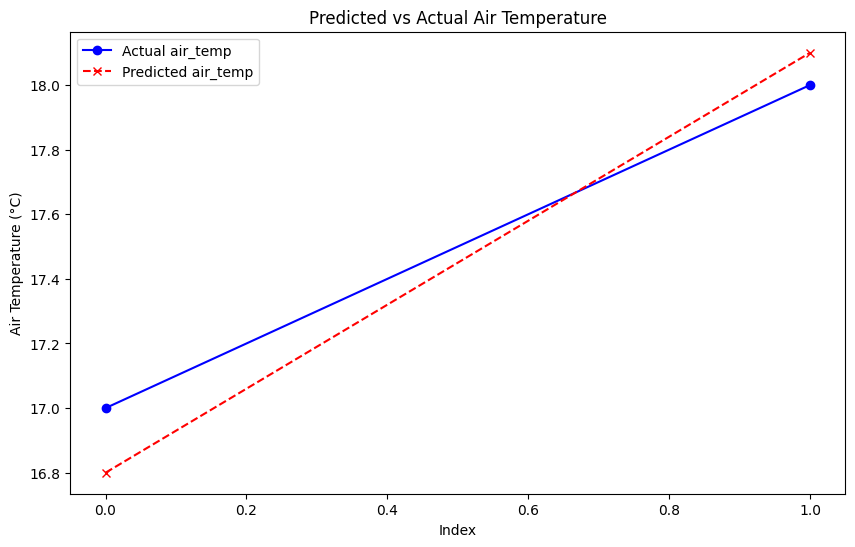

In [30]:
# Visualisasi hasil prediksi vs nilai asli
plt.figure(figsize=(10, 6))
plt.plot(y_test, label="Actual air_temp", color="blue", marker="o")
plt.plot(y_pred, label="Predicted air_temp", color="red", linestyle="--", marker="x")
plt.title("Predicted vs Actual Air Temperature")
plt.xlabel("Index")
plt.ylabel("Air Temperature (°C)")
plt.legend()
plt.show()


In [31]:
import joblib

# Simpan model
joblib.dump(model, 'air_temp_predictor_model.pkl')

# Untuk memuat model di masa depan:
# loaded_model = joblib.load('air_temp_predictor_model.pkl')


['air_temp_predictor_model.pkl']

## melakukan uji coba pada model yang di latih untuk melakukan prediksi

In [33]:
# Fungsi untuk melakukan prediksi 3 hari ke depan
def predict_3_days_ahead(model, data, window_size):
    predictions = []
    # current_input = data[-window_size:].drop(columns=["air_temp"]).values  # Ambil window terakhir sebagai input
    current_input = data[["air_temp", "air_pressure", "avg_wind_speed", "relative_humidity"]][-window_size:].values

    for _ in range(3):  # Prediksi selama 3 hari berturut-turut
        # Prediksi untuk hari ini
        predicted_temp = model.predict(current_input.reshape(1, -1))
        predictions.append(predicted_temp[0])

        # Update input window dengan prediksi
        # Untuk hari berikutnya, kita tambahkan prediksi ke dalam window dan geser

        # Create a new row with the predicted temperature
        new_row = pd.DataFrame([[predicted_temp[0], data["air_pressure"].iloc[-1], data["avg_wind_speed"].iloc[-1], data["relative_humidity"].iloc[-1]]],
                               columns=["air_temp", "air_pressure", "avg_wind_speed", "relative_humidity"])

        # Append the new row to the data DataFrame
        data = pd.concat([data, new_row], ignore_index=True)

        # Update current_input for the next prediction
        current_input = data[["air_temp", "air_pressure", "avg_wind_speed", "relative_humidity"]][-window_size:].values


    return predictions

# Prediksi 3 hari ke depan
predicted_3_days = predict_3_days_ahead(model, data.copy(), window_size) # Create a copy of data to avoid modifying the original DataFrame

# Tampilkan hasil prediksi
print(f"Prediksi 3 hari ke depan: {predicted_3_days}")

Prediksi 3 hari ke depan: [58.53560000000002, 58.54460000000003, 58.47800000000002]


## Hasil Deploy

ini adalah hasil deploy untuk prediksi ini :
https://huggingface.co/spaces/yudhanuurcahyo/psd_prediksi_tugas3
